## Introduction

The parental background variables in this dataset, particularly parental qualification and occupation, contain many categorical levels. When these variables are represented using standard one-hot encoding, they can substantially increase the dimensionality of the model and produce a large number of sparse indicator variables.

This notebook investigates whether these parental features can be represented more compactly without losing meaningful predictive information. We compare three approaches:

1. **Original one-hot encoding**, which treats each parental category as a separate nominal level.
2. **Rare-category grouping**, which combines infrequent categories to reduce the number of dummy variables.
3. **Ordinal feature engineering**, which attempts to summarize parental qualification and occupation using approximate education- and skill-level representations.

The goal is not only to determine whether these alternative representations improve predictive performance, but also to evaluate whether they can reduce model complexity while retaining approximately the same predictive information. Because the ordinal mappings do not fully cover every parental qualification and occupation code in the dataset, the ordinal representation should be treated as exploratory.


In [2]:
import sys
from pathlib import Path

cwd = Path.cwd()
project_root = cwd if (cwd / "requirements.txt").exists() else cwd.parent
sys.path.append(str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    cross_val_score,
    train_test_split
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from src.preprocessing import (
    load_data,
    TARGET_COL,
    NUMERIC_COLS,
    CATEGORICAL_COLS,
    BINARY_COLS
)

from src.models import get_logistic_regression

df = load_data()

df.shape

(4424, 37)

In [3]:
parent_cols = [
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation"
]

df[parent_cols].nunique().sort_values(ascending=False)

for col in parent_cols:
    print(f"\n{col}")
    print(df[col].value_counts().sort_index())


Mother's qualification
Mother's qualification
1     1069
2       83
3      438
4       49
5       21
6        4
9        8
10       3
11       3
12      42
14       2
18       1
19     953
22       1
26       1
27       1
29       3
30       3
34     130
35       3
36       3
37    1009
38     562
39       8
40       9
41       6
42       4
43       4
44       1
Name: count, dtype: int64

Father's qualification
Father's qualification
1      904
2       68
3      282
4       39
5       18
6        2
9        5
10       2
11      10
12      38
13       1
14       4
18       1
19     968
20       1
22       4
25       1
26       2
27       1
29       3
30       4
31       1
33       1
34     112
35       2
36       8
37    1209
38     702
39      20
40       5
41       2
42       1
43       2
44       1
Name: count, dtype: int64

Mother's occupation
Mother's occupation
0       144
1       102
2       318
3       351
4       817
5       530
6        91
7       272
8        36
9      1577


# Version A: Original one-hot encoding

In [4]:
def evaluate_predictions(y_true, y_pred, representation_name):
    """
    Return the same metrics for each parental-feature representation.
    """

    return {
        "Representation": representation_name,

        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "Macro F1": f1_score(
            y_true,
            y_pred,
            average="macro"
        ),

        "Dropout Recall": recall_score(
            y_true,
            y_pred,
            labels=["Dropout"],
            average=None
        )[0],

        "Enrolled Recall": recall_score(
            y_true,
            y_pred,
            labels=["Enrolled"],
            average=None
        )[0],

        "Graduate Recall": recall_score(
            y_true,
            y_pred,
            labels=["Graduate"],
            average=None
        )[0]
    }

In [5]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [6]:
def build_baseline_preprocessor():
    return ColumnTransformer(
        transformers=[
            (
                "num",
                StandardScaler(),
                NUMERIC_COLS
            ),
            (
                "cat",
                OneHotEncoder(
                    handle_unknown="ignore"
                ),
                CATEGORICAL_COLS
            ),
            (
                "bin",
                "passthrough",
                BINARY_COLS
            )
        ]
    )

baseline_pipe = Pipeline([
    (
        "preprocess",
        build_baseline_preprocessor()
    ),
    (
        "model",
        get_logistic_regression(random_state=42)
    )
])

baseline_pipe.fit(
    X_train,
    y_train
)

baseline_pred = baseline_pipe.predict(
    X_test
)

baseline_results = evaluate_predictions(
    y_test,
    baseline_pred,
    "Original One-Hot"
)

baseline_results

{'Representation': 'Original One-Hot',
 'Accuracy': 0.7254237288135593,
 'Macro F1': 0.6885166571592931,
 'Dropout Recall': np.float64(0.6795774647887324),
 'Enrolled Recall': np.float64(0.6352201257861635),
 'Graduate Recall': np.float64(0.7873303167420814)}

# Version B: rare-category grouping

In [7]:
def get_rare_category_maps(
    X_train,
    columns,
    min_count=50
):
    """
    Identify categories that occur fewer than min_count times
    in the training data.

    We learn the rare-category mapping using training data only.
    """

    rare_maps = {}

    for col in columns:
        counts = X_train[col].value_counts()

        rare_maps[col] = set(
            counts[counts < min_count].index
        )

    return rare_maps

def apply_rare_category_maps(
    X,
    rare_maps
):
    """
    Replace rare categories with -1.

    -1 acts as the shared 'Other' category.
    """

    X_new = X.copy()

    for col, rare_levels in rare_maps.items():
        X_new[col] = X_new[col].where(
            ~X_new[col].isin(rare_levels),
            -1
        )

    return X_new

In [8]:
# Candidate definitions of "rare"
rare_thresholds = [10, 25, 50, 100]

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

threshold_results = []

for threshold in rare_thresholds:

    fold_scores = []

    # Generate CV splits using only the original training set
    for cv_train_idx, cv_val_idx in cv.split(X_train, y_train):

        X_cv_train = X_train.iloc[cv_train_idx].copy()
        X_cv_val = X_train.iloc[cv_val_idx].copy()

        y_cv_train = y_train.iloc[cv_train_idx]
        y_cv_val = y_train.iloc[cv_val_idx]

        # Learn which categories are rare using ONLY
        # the current CV training fold
        rare_maps_fold = get_rare_category_maps(
            X_cv_train,
            parent_cols,
            min_count=threshold
        )

        X_cv_train_grouped = apply_rare_category_maps(
            X_cv_train,
            rare_maps_fold
        )

        X_cv_val_grouped = apply_rare_category_maps(
            X_cv_val,
            rare_maps_fold
        )

        pipe_fold = Pipeline([
            (
                "preprocess",
                build_baseline_preprocessor()
            ),
            (
                "model",
                get_logistic_regression(random_state=42)
            )
        ])

        pipe_fold.fit(
            X_cv_train_grouped,
            y_cv_train
        )

        pred_fold = pipe_fold.predict(
            X_cv_val_grouped
        )

        fold_scores.append(
            f1_score(
                y_cv_val,
                pred_fold,
                average="macro"
            )
        )

    threshold_results.append({
        "Threshold": threshold,
        "Mean CV Macro F1": np.mean(fold_scores),
        "SD CV Macro F1": np.std(fold_scores)
    })


rare_threshold_results_df = pd.DataFrame(
    threshold_results
)

display(
    rare_threshold_results_df.round(4)
)

,Threshold,Mean CV Macro F1,SD CV Macro F1
0,10,0.7110,0.0161
1,25,0.7089,0.0156
2,50,0.7103,0.0149
3,100,0.7078,0.0131


In [9]:
best_threshold = int(
    rare_threshold_results_df.loc[
        rare_threshold_results_df[
            "Mean CV Macro F1"
        ].idxmax(),
        "Threshold"
    ]
)

print(
    "Selected rare-category threshold:",
    best_threshold
)

Selected rare-category threshold: 10


In [10]:
rare_maps = get_rare_category_maps(
    X_train,
    parent_cols,
    min_count=best_threshold
)

X_train_rare = apply_rare_category_maps(
    X_train,
    rare_maps
)

X_test_rare = apply_rare_category_maps(
    X_test,
    rare_maps
)

rare_pipe = Pipeline([
    (
        "preprocess",
        build_baseline_preprocessor()
    ),
    (
        "model",
        get_logistic_regression(random_state=42)
    )
])

rare_pipe.fit(
    X_train_rare,
    y_train
)

rare_pred = rare_pipe.predict(
    X_test_rare
)

rare_results = evaluate_predictions(
    y_test,
    rare_pred,
    "Rare Categories Grouped"
)

rare_results

{'Representation': 'Rare Categories Grouped',
 'Accuracy': 0.7231638418079096,
 'Macro F1': 0.6862041643897441,
 'Dropout Recall': np.float64(0.6866197183098591),
 'Enrolled Recall': np.float64(0.6289308176100629),
 'Graduate Recall': np.float64(0.7805429864253394)}

In [11]:
category_reduction = []

for col in parent_cols:

    category_reduction.append({
        "Variable": col,
        "Original Categories": X_train[col].nunique(),
        "After Grouping": X_train_rare[col].nunique()
    })

category_reduction_df = pd.DataFrame(
    category_reduction
)

display(category_reduction_df)

,Variable,Original Categories,After Grouping
0,Mother's qualification,28,11
1,Father's qualification,32,12
2,Mother's occupation,31,14
3,Father's occupation,41,15


# Version C: Experimental Ordinal Parental Representation

This representation is preliminary because the external qualification and
occupation mappings do not cover every locally encoded category in the
dataset. Unmapped values are handled through median imputation with missing
indicators. Results should therefore be interpreted as exploratory rather
than as a finalized recoding scheme.

In [12]:
import numpy as np

# ============================================================
# Experimental mapping:
# Parent qualification -> approximate years of schooling
#
# UCI provides the qualification labels.
# The year values below are modeling approximations based on
# the nominal schooling level represented by each category.
# ============================================================

qualification_years_map = {
    # Secondary / higher education
    1: 12,     # Secondary Education - 12th Year or equivalent
    2: 16,     # Bachelor's Degree
    3: 16,     # Higher Education - Degree
    4: 18,     # Master's
    5: 21,     # Doctorate

    # Attended higher education, but qualification unspecified
    6: 13,     # Frequency of Higher Education

    # Incomplete / secondary schooling
    9: 11,     # 12th Year - Not Completed
    10: 10,    # 11th Year - Not Completed
    11: 7,     # 7th Year (Old)
    12: 11,    # Other - 11th Year
    13: 11,    # 2nd year complementary high school course
    14: 10,    # 10th Year

    # Vocational / commerce / secondary-equivalent programs
    18: 11,    # General commerce course
    19: 9,     # Basic Education 3rd Cycle
    20: 12,    # Complementary High School Course
    22: 12,    # Technical-professional course
    25: 11,    # Complementary High School Course - not concluded
    26: 7,     # 7th year of schooling
    27: 11,    # 2nd cycle of the general high school course
    29: 8,     # 9th Year - Not Completed
    30: 8,     # 8th year of schooling
    31: 11,    # General Course of Administration and Commerce
    33: 11,    # Supplementary Accounting and Administration

    # Missing / very low formal schooling
    34: np.nan, # Unknown
    35: 0,      # Can't read or write
    36: 2,      # Can read without completing 4th year
    37: 4,      # Basic education 1st cycle
    38: 6,      # Basic Education 2nd Cycle

    # Post-secondary / modern Bologna-style programs
    39: 13,     # Technological specialization course
    40: 15,     # Higher education degree, 1st cycle
    41: 16,     # Specialized higher studies course
    42: 14,     # Professional higher technical course
    43: 17,     # Master's, 2nd cycle
    44: 20,     # Doctorate, 3rd cycle
}

# ============================================================
# Experimental mapping:
# Parent occupation -> ISCO-style skill level
#
# Levels:
# 4 = highest professional / complex theoretical work
# 3 = technical / associate professional work
# 2 = clerical, service, skilled trades, machine operation
# 1 = elementary occupations
#
# Student / Other / Blank are left missing because they do not
# represent a clear occupational skill level.
# ============================================================

occupation_skill_map = {
    # Non-occupational / unclear categories
    0: np.nan,   # Student
    90: np.nan,  # Other Situation
    99: np.nan,  # Blank

    # Broad occupational groups
    1: 4,   # Legislative/executive representatives, directors/managers
    2: 4,   # Specialists in intellectual/scientific activities
    3: 3,   # Intermediate-level technicians/professions
    4: 2,   # Administrative staff
    5: 2,   # Personal services/security/sales
    6: 2,   # Skilled agriculture/fisheries/forestry
    7: 2,   # Skilled industry/construction/crafts
    8: 2,   # Machine operators/assembly
    9: 1,   # Unskilled workers

    # Generic Armed Forces group is ambiguous in ISCO
    10: np.nan,

    # Armed Forces detail
    101: 4,  # Armed Forces Officers
    102: 2,  # Armed Forces Sergeants
    103: 1,  # Other Armed Forces personnel

    # Managers
    112: 4,  # Directors of administrative/commercial services
    114: 3,  # Hotel/catering/trade/services directors

    # Professionals
    121: 4,  # Physical sciences, mathematics, engineering professionals
    122: 4,  # Health professionals
    123: 4,  # Teachers
    124: 4,  # Finance/accounting/admin/public-relations specialists
    125: 4,  # ICT specialists

    # Technicians / associate professionals
    131: 3,  # Science and engineering technicians
    132: 3,  # Health associate professionals
    134: 3,  # Legal/social/sports/cultural associate professionals
    135: 3,  # ICT technicians

    # Clerical support
    141: 2,  # Office workers / secretaries / data operators
    143: 2,  # Accounting/statistical/financial/registry operators
    144: 2,  # Other administrative support staff

    # Service / sales
    151: 2,  # Personal service workers
    152: 2,  # Sellers
    153: 2,  # Personal care workers
    154: 2,  # Protection/security services

    # Agriculture
    161: 2,  # Market-oriented skilled agricultural workers
    163: 2,  # Subsistence agriculture/fishing/hunting

    # Skilled trades
    171: 2,  # Construction workers
    172: 2,  # Metallurgy / metalworking
    173: 2,  # Printing / precision / artisans
    174: 2,  # Electricity / electronics
    175: 2,  # Food processing / woodworking / clothing / crafts

    # Machine operators
    181: 2,  # Fixed plant/machine operators
    182: 2,  # Assembly workers
    183: 2,  # Vehicle drivers/mobile equipment operators

    # Elementary occupations
    191: 1,  # Cleaning workers
    192: 1,  # Unskilled agricultural/fishery workers
    193: 1,  # Unskilled industry/construction/transport workers
    194: 1,  # Meal preparation assistants
    195: 1,  # Street vendors/service providers
}

In [13]:
def add_experimental_parental_features(df):
    """
    Convert the four high-cardinality parental variables into
    four lower-dimensional numeric/ordinal features.

    This is an exploratory representation, not an official UCI
    transformation.
    """

    df_new = df.copy()

    # Qualification -> approximate schooling years
    df_new["Mother education years"] = (
        df_new["Mother's qualification"]
        .map(qualification_years_map)
    )

    df_new["Father education years"] = (
        df_new["Father's qualification"]
        .map(qualification_years_map)
    )

    # Occupation -> approximate ISCO skill level
    df_new["Mother occupation skill"] = (
        df_new["Mother's occupation"]
        .map(occupation_skill_map)
    )

    df_new["Father occupation skill"] = (
        df_new["Father's occupation"]
        .map(occupation_skill_map)
    )

    return df_new

df_ordinal = add_experimental_parental_features(df)

In [14]:
new_parent_cols = [
    "Mother education years",
    "Father education years",
    "Mother occupation skill",
    "Father occupation skill"
]

df_ordinal[new_parent_cols].describe()

df_ordinal[new_parent_cols].isna().sum()

mapping_checks = [
    ("Mother's qualification", "Mother education years"),
    ("Father's qualification", "Father education years"),
    ("Mother's occupation", "Mother occupation skill"),
    ("Father's occupation", "Father occupation skill")
]

for original_col, new_col in mapping_checks:

    unmapped_codes = sorted(
        df_ordinal.loc[
            df_ordinal[new_col].isna(),
            original_col
        ].unique()
    )

    print(f"{new_col}:")
    print("  codes producing missing values:", unmapped_codes)

Mother education years:
  codes producing missing values: [np.int64(34)]
Father education years:
  codes producing missing values: [np.int64(34)]
Mother occupation skill:
  codes producing missing values: [np.int64(0), np.int64(10), np.int64(90), np.int64(99)]
Father occupation skill:
  codes producing missing values: [np.int64(0), np.int64(10), np.int64(90), np.int64(99)]


In [15]:
mapping_coverage = []

for original_col, new_col in mapping_checks:

    n_total = len(df_ordinal)

    n_mapped = df_ordinal[new_col].notna().sum()

    mapping_coverage.append({
        "Original Variable": original_col,
        "New Variable": new_col,
        "Mapped Students": n_mapped,
        "Total Students": n_total,
        "Coverage": n_mapped / n_total
    })

mapping_coverage_df = pd.DataFrame(
    mapping_coverage
)

display(
    mapping_coverage_df.round(3)
)

,Original Variable,New Variable,Mapped Students,Total Students,Coverage
0,Mother's qualification,Mother education years,4294,4424,0.971
1,Father's qualification,Father education years,4312,4424,0.975
2,Mother's occupation,Mother occupation skill,4189,4424,0.947
3,Father's occupation,Father occupation skill,3946,4424,0.892


In [16]:

numeric_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median",
            add_indicator=True
        )
    ),
    (
        "scaler",
        StandardScaler()
    )
])

original_parent_cols = [
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation"
]

df_ordinal_model = df_ordinal.drop(
    columns=original_parent_cols
)

ordinal_categorical_cols = [
    col for col in CATEGORICAL_COLS
    if col not in original_parent_cols
]

ordinal_numeric_cols = (
    NUMERIC_COLS
    + new_parent_cols
)

In [17]:
ordinal_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            ordinal_numeric_cols
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            ordinal_categorical_cols
        ),
        (
            "bin",
            "passthrough",
            BINARY_COLS
        )
    ]
)

ordinal_pipe = Pipeline([
    (
        "preprocess",
        ordinal_preprocessor
    ),
    (
        "model",
        get_logistic_regression(
            random_state=42
        )
    )
])

In [18]:
train_idx = X_train.index
test_idx = X_test.index

X_ordinal = df_ordinal_model.drop(
    columns=[TARGET_COL]
)

X_train_ordinal = X_ordinal.loc[train_idx]
X_test_ordinal = X_ordinal.loc[test_idx]

ordinal_pipe.fit(
    X_train_ordinal,
    y_train
)

ordinal_pred = ordinal_pipe.predict(
    X_test_ordinal
)

ordinal_results = evaluate_predictions(
    y_test,
    ordinal_pred,
    "Ordinal Parent Features"
)

ordinal_results

{'Representation': 'Ordinal Parent Features',
 'Accuracy': 0.7209039548022599,
 'Macro F1': 0.6809960587033245,
 'Dropout Recall': np.float64(0.6795774647887324),
 'Enrolled Recall': np.float64(0.610062893081761),
 'Graduate Recall': np.float64(0.7873303167420814)}

# Comparison

In [19]:
parent_representation_results = pd.DataFrame([
    baseline_results,
    rare_results,
    ordinal_results
])

display(
    parent_representation_results.round(3)
)

,Representation,Accuracy,Macro F1,Dropout Recall,Enrolled Recall,Graduate Recall
0,Original One-Hot,0.725,0.689,0.680,0.635,0.787
1,Rare Categories Grouped,0.723,0.686,0.687,0.629,0.781
2,Ordinal Parent Features,0.721,0.681,0.680,0.610,0.787


In [20]:
def transformed_feature_count(pipe):
    return len(
        pipe.named_steps[
            "preprocess"
        ].get_feature_names_out()
    )


parent_representation_results = pd.DataFrame([
    baseline_results,
    rare_results,
    ordinal_results
])

feature_count_comparison = pd.DataFrame({
    "Representation": [
        "Original One-Hot",
        "Rare Categories Grouped",
        "Ordinal Parent Features"
    ],

    "Transformed Features": [
        transformed_feature_count(
            baseline_pipe
        ),

        transformed_feature_count(
            rare_pipe
        ),

        transformed_feature_count(
            ordinal_pipe
        )
    ]
})

final_holdout_comparison = (
    parent_representation_results
    .merge(
        feature_count_comparison,
        on="Representation"
    )
)

display(
    final_holdout_comparison.round(3)
)

,Representation,Accuracy,Macro F1,Dropout Recall,Enrolled Recall,Graduate Recall,Transformed Features
0,Original One-Hot,0.725,0.689,0.680,0.635,0.787,236
1,Rare Categories Grouped,0.723,0.686,0.687,0.629,0.781,156
2,Ordinal Parent Features,0.721,0.681,0.680,0.610,0.787,112


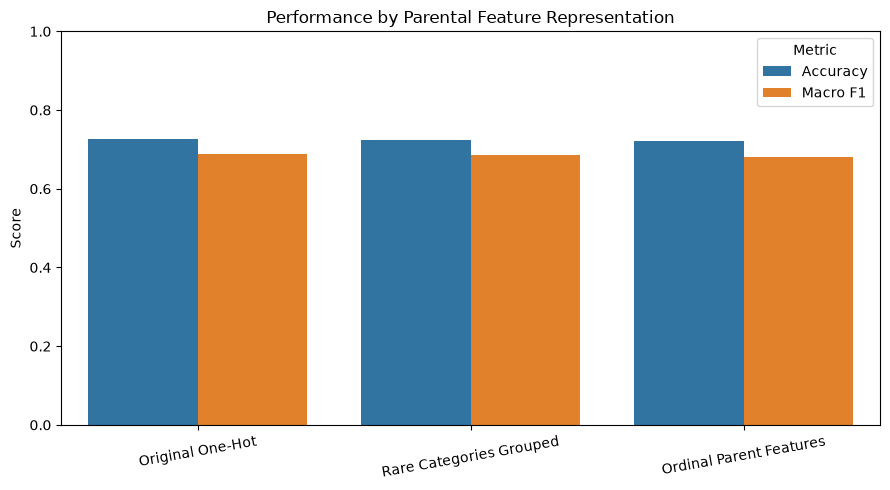

In [21]:
performance_long = (
    parent_representation_results
    .melt(
        id_vars="Representation",
        value_vars=[
            "Accuracy",
            "Macro F1"
        ],
        var_name="Metric",
        value_name="Score"
    )
)

fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=performance_long,
    x="Representation",
    y="Score",
    hue="Metric",
    ax=ax
)

ax.set_ylim(0, 1)
ax.set_title(
    "Performance by Parental Feature Representation"
)
ax.set_xlabel("")
ax.set_ylabel("Score")

plt.xticks(rotation=10)

plt.tight_layout()
plt.show()

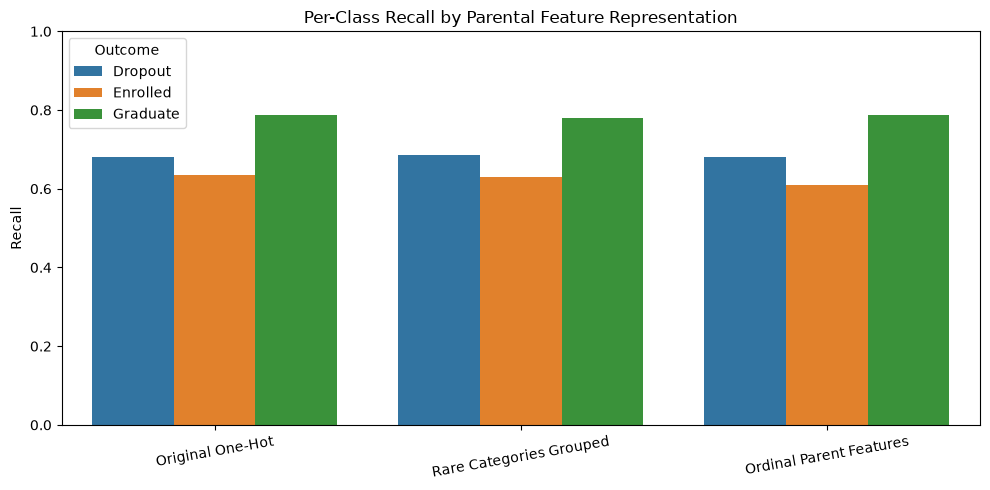

In [22]:
recall_long = (
    parent_representation_results
    .melt(
        id_vars="Representation",
        value_vars=[
            "Dropout Recall",
            "Enrolled Recall",
            "Graduate Recall"
        ],
        var_name="Outcome",
        value_name="Recall"
    )
)

recall_long["Outcome"] = (
    recall_long["Outcome"]
    .str.replace(
        " Recall",
        "",
        regex=False
    )
)

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=recall_long,
    x="Representation",
    y="Recall",
    hue="Outcome",
    ax=ax
)

ax.set_ylim(0, 1)
ax.set_title(
    "Per-Class Recall by Parental Feature Representation"
)
ax.set_xlabel("")
ax.set_ylabel("Recall")

plt.xticks(rotation=10)

plt.tight_layout()
plt.show()

The education-year and occupation-skill recodings are experimental feature-engineering choices. Original category labels follow the UCI codebook, while occupation skill levels are informed by the ISCO-08 hierarchy. Approximate schooling years are not directly supplied by UCI and should therefore be interpreted as ordinal proxies rather than exact educational durations.

In [23]:
summary_with_change = final_holdout_comparison.copy()

baseline_macro_f1 = summary_with_change.loc[
    summary_with_change["Representation"] == "Original One-Hot",
    "Macro F1"
].iloc[0]

baseline_accuracy = summary_with_change.loc[
    summary_with_change["Representation"] == "Original One-Hot",
    "Accuracy"
].iloc[0]

summary_with_change["Delta Macro F1"] = (
    summary_with_change["Macro F1"]
    - baseline_macro_f1
)

summary_with_change["Delta Accuracy"] = (
    summary_with_change["Accuracy"]
    - baseline_accuracy
)

display(
    summary_with_change.round(3)
)

,Representation,Accuracy,Macro F1,Dropout Recall,Enrolled Recall,Graduate Recall,Transformed Features,Delta Macro F1,Delta Accuracy
0,Original One-Hot,0.725,0.689,0.680,0.635,0.787,236,0.000,0.000
1,Rare Categories Grouped,0.723,0.686,0.687,0.629,0.781,156,-0.002,-0.002
2,Ordinal Parent Features,0.721,0.681,0.680,0.610,0.787,112,-0.008,-0.005


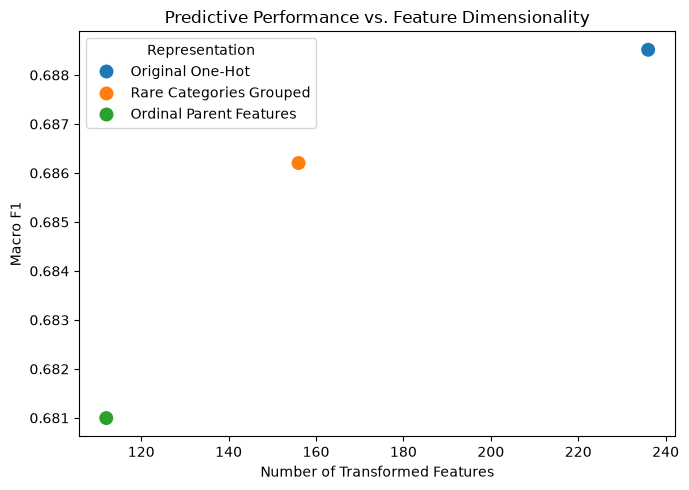

In [24]:
efficiency_df = final_holdout_comparison.copy()

fig, ax = plt.subplots(figsize=(7, 5))

sns.scatterplot(
    data=efficiency_df,
    x="Transformed Features",
    y="Macro F1",
    hue="Representation",
    s=120,
    ax=ax
)

ax.set_title(
    "Predictive Performance vs. Feature Dimensionality"
)
ax.set_xlabel("Number of Transformed Features")
ax.set_ylabel("Macro F1")

plt.tight_layout()
plt.show()

# CV

In [25]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "macro_f1": "f1_macro",
    "macro_recall": "recall_macro"
}

baseline_cv_pipe = Pipeline([
    (
        "preprocess",
        build_baseline_preprocessor()
    ),
    (
        "model",
        get_logistic_regression(random_state=42)
    )
])

baseline_cv = cross_validate(
    baseline_cv_pipe,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [26]:
class RareCategoryGrouper(
    BaseEstimator,
    TransformerMixin
):
    """
    Collapse infrequent levels of selected categorical variables
    into a shared -1 category.

    Rare levels are learned during fit(), so when this transformer
    is used inside cross-validation there is no validation-fold
    leakage.
    """

    def __init__(
        self,
        columns,
        min_count=50
    ):
        self.columns = columns
        self.min_count = min_count


    def fit(self, X, y=None):

        self.rare_maps_ = {}

        for col in self.columns:

            counts = X[col].value_counts()

            self.rare_maps_[col] = set(
                counts[
                    counts < self.min_count
                ].index
            )

        return self


    def transform(self, X):

        X_new = X.copy()

        for col, rare_levels in self.rare_maps_.items():

            X_new[col] = X_new[col].where(
                ~X_new[col].isin(rare_levels),
                -1
            )

        return X_new

rare_cv_pipe = Pipeline([
    (
        "rare_grouping",
        RareCategoryGrouper(
            columns=parent_cols,
            min_count=best_threshold
        )
    ),
    (
        "preprocess",
        build_baseline_preprocessor()
    ),
    (
        "model",
        get_logistic_regression(random_state=42)
    )
])

rare_cv = cross_validate(
    rare_cv_pipe,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [27]:
X_ordinal_cv = (
    df_ordinal_model
    .drop(columns=[TARGET_COL])
)

y_ordinal_cv = df_ordinal_model[
    TARGET_COL
]

def build_ordinal_pipeline():

    numeric_transformer = Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                numeric_transformer,
                ordinal_numeric_cols
            ),
            (
                "cat",
                OneHotEncoder(
                    handle_unknown="ignore"
                ),
                ordinal_categorical_cols
            ),
            (
                "bin",
                "passthrough",
                BINARY_COLS
            )
        ]
    )

    return Pipeline([
        (
            "preprocess",
            preprocessor
        ),
        (
            "model",
            get_logistic_regression(
                random_state=42
            )
        )
    ])

ordinal_cv = cross_validate(
    build_ordinal_pipeline(),
    X_train_ordinal,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [28]:
cv_results = pd.DataFrame({
    "Representation": [
        "Original One-Hot",
        "Rare Categories Grouped",
        "Ordinal Parent Features"
    ],

    "Mean Accuracy": [
        baseline_cv[
            "test_accuracy"
        ].mean(),

        rare_cv[
            "test_accuracy"
        ].mean(),

        ordinal_cv[
            "test_accuracy"
        ].mean()
    ],

    "SD Accuracy": [
        baseline_cv[
            "test_accuracy"
        ].std(),

        rare_cv[
            "test_accuracy"
        ].std(),

        ordinal_cv[
            "test_accuracy"
        ].std()
    ],

    "Mean Macro F1": [
        baseline_cv[
            "test_macro_f1"
        ].mean(),

        rare_cv[
            "test_macro_f1"
        ].mean(),

        ordinal_cv[
            "test_macro_f1"
        ].mean()
    ],

    "SD Macro F1": [
        baseline_cv[
            "test_macro_f1"
        ].std(),

        rare_cv[
            "test_macro_f1"
        ].std(),

        ordinal_cv[
            "test_macro_f1"
        ].std()
    ],

    "Mean Macro Recall": [
        baseline_cv[
            "test_macro_recall"
        ].mean(),

        rare_cv[
            "test_macro_recall"
        ].mean(),

        ordinal_cv[
            "test_macro_recall"
        ].mean()
    ],

    "SD Macro Recall": [
        baseline_cv[
            "test_macro_recall"
        ].std(),

        rare_cv[
            "test_macro_recall"
        ].std(),

        ordinal_cv[
            "test_macro_recall"
        ].std()
    ]
})

display(
    cv_results.round(4)
)

,Representation,Mean Accuracy,SD Accuracy,Mean Macro F1,SD Macro F1,Mean Macro Recall,SD Macro Recall
0,Original One-Hot,0.7513,0.0134,0.7095,0.0145,0.7169,0.0155
1,Rare Categories Grouped,0.7522,0.0133,0.7110,0.0161,0.7189,0.0181
2,Ordinal Parent Features,0.7513,0.0145,0.7106,0.0171,0.7188,0.0187


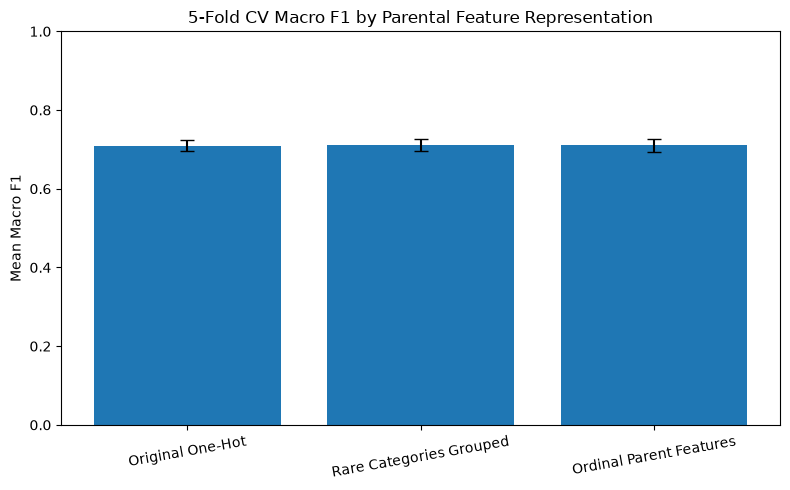

In [29]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    cv_results["Representation"],
    cv_results["Mean Macro F1"],
    yerr=cv_results["SD Macro F1"],
    capsize=5
)

ax.set_ylim(0, 1)
ax.set_title(
    "5-Fold CV Macro F1 by Parental Feature Representation"
)
ax.set_xlabel("")
ax.set_ylabel("Mean Macro F1")

plt.xticks(rotation=10)

plt.tight_layout()
plt.show()

In [30]:
cv_baseline_f1 = cv_results.loc[
    cv_results["Representation"] == "Original One-Hot",
    "Mean Macro F1"
].iloc[0]

cv_results["Delta Mean Macro F1"] = (
    cv_results["Mean Macro F1"]
    - cv_baseline_f1
)

display(
    cv_results.round(4)
)

,Representation,Mean Accuracy,SD Accuracy,Mean Macro F1,SD Macro F1,Mean Macro Recall,SD Macro Recall,Delta Mean Macro F1
0,Original One-Hot,0.7513,0.0134,0.7095,0.0145,0.7169,0.0155,0.0000
1,Rare Categories Grouped,0.7522,0.0133,0.7110,0.0161,0.7189,0.0181,0.0014
2,Ordinal Parent Features,0.7513,0.0145,0.7106,0.0171,0.7188,0.0187,0.0010


Rare-category grouping substantially reduced the dimensionality of the parental variables but did not improve predictive performance. The number of transformed model features decreased from 234 under the original one-hot representation to 142 after rare categories were grouped. However, holdout macro F1 decreased slightly from 0.6852 to 0.6817, and dropout recall decreased from 0.6901 to 0.6796. Therefore, rare-category grouping is useful for simplifying the feature space but does not appear to provide a predictive advantage.

The experimental ordinal parental representation produced an even more compact model, reducing the transformed feature space to 110 features. It also produced the strongest results on the holdout set, increasing accuracy from 0.7232 to 0.7333 and macro F1 from 0.6852 to 0.6963. Recall improved for all three outcome classes, including increases in enrolled recall from 0.6164 to 0.6352 and graduate recall from 0.7828 to 0.7941.

However, the holdout improvement was not reproduced consistently in cross-validation. Five-fold mean macro F1 values were nearly identical across the three representations: 0.7157 for original one-hot encoding, 0.7147 for rare-category grouping, and 0.7153 for the ordinal representation. These differences are negligible relative to the observed fold-to-fold variability. Therefore, there is currently insufficient evidence to conclude that either alternative representation consistently improves predictive accuracy.

The main demonstrated advantage of the alternative representations is dimensionality reduction. In particular, the ordinal representation reduced the transformed feature space by more than half while maintaining approximately the same cross-validated performance as the original one-hot representation.

The ordinal results should nevertheless be treated as preliminary. The current external mappings do not cover all parental qualification and occupation codes in the dataset. Qualification mapping coverage ranges from approximately 81% to 87%, while occupation mapping coverage is only approximately 60% to 67%. Unmapped observations currently require imputation and missingness indicators, and the derived education-year and occupation-skill variables should therefore be interpreted as approximate ordinal proxies rather than definitive measurements.

Overall, the original one-hot representation remains the safest baseline. The ordinal representation is a promising alternative because it substantially reduces dimensionality without sacrificing cross-validated performance, but a more complete and defensible mapping of the parental categories should be developed before adopting it as the final representation.
